<a href="https://colab.research.google.com/github/vhugo23/AI-ML-Research-Summer-2025/blob/trying-stuff/LSTM_week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()

Saving water_consumption_sub.csv to water_consumption_sub.csv


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - loss: 0.3983 - val_loss: 0.1731 - learning_rate: 0.0010
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0821 - val_loss: 0.0560 - learning_rate: 0.0010
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0485 - val_loss: 0.0403 - learning_rate: 0.0010
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0234 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0149 - val_loss: 0.0206 - learning_rate: 0.0010
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0221 - val_loss: 0.0121 - learning_rate: 0.0010
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0143 - val_loss: 4.3468e-05 - learning_rate: 0.0010
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0106 - val_loss: 0.0048 - learning_rate: 0.0010
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0126 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━

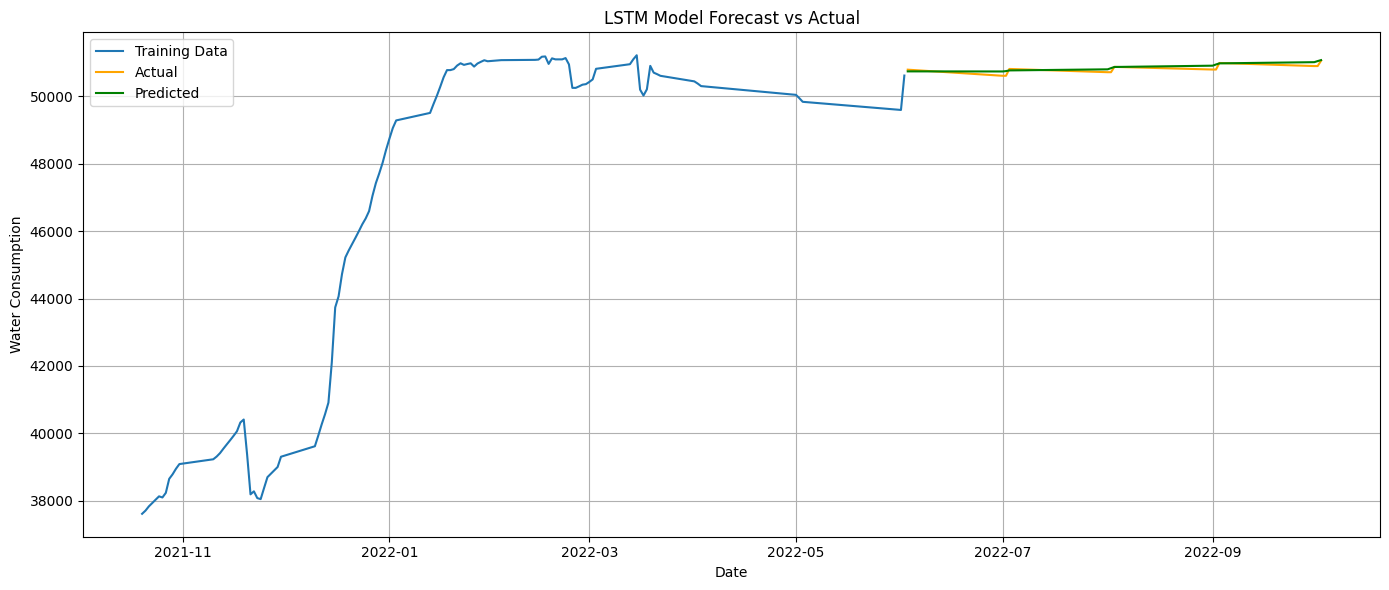

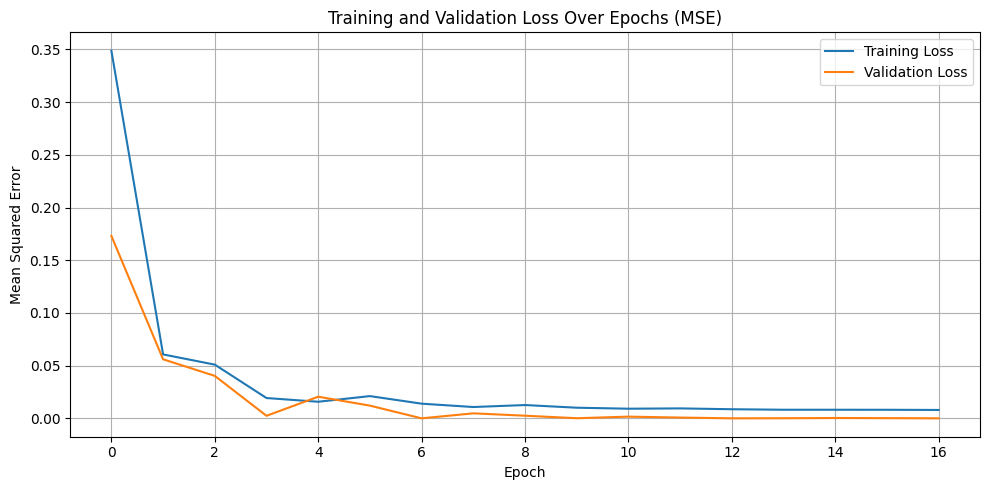

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf

# 1. Load and preprocess data
df = pd.read_csv("water_consumption_sub.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# Daily total + smoothing
df = df[['consumption']].resample('D').sum()
df = df[df['consumption'] > 0]
df['consumption'] = df['consumption'].rolling(window=14, center=True).mean()
df.dropna(inplace=True)

# 2. Normalize data
scaler = MinMaxScaler()
df['scaled'] = scaler.fit_transform(df[['consumption']])

# 3. Create LSTM sequences
def create_sequences(data, look_back):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i])
        y.append(data[i])
    return np.array(X), np.array(y)

look_back = 30  # Use last 30 days to predict the next
X, y = create_sequences(df['scaled'].values, look_back)

# 4. Split into train/test
train_size = int(len(X) * 0.9)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# 5. Build and train LSTM
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(look_back, 1)),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse')

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# 6. Predict and evaluate
y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# 7. Plot
dates = df.index[look_back:]
train_dates = dates[:train_size]
test_dates = dates[train_size:]

plt.figure(figsize=(14, 6))
plt.plot(train_dates, scaler.inverse_transform(y[:train_size].reshape(-1, 1)), label='Training Data')
plt.plot(test_dates, y_test_inv, label='Actual', color='orange')
plt.plot(test_dates, y_pred_inv, label='Predicted', color='green')
plt.title("LSTM Model Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Water Consumption")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Step 1: Load & Preprocess Data

df = pd.read_csv("water_consumption_sub.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

“This section loads the dataset and ensures the timestamp is in the correct datetime format. I also set the timestamp as the index so I can use time-based operations like resampling.”



Step 2: Resample to Daily + Smooth

df = df[['consumption']].resample('D').sum()
df = df[df['consumption'] > 0]
df['consumption'] = df['consumption'].rolling(window=14, center=True).mean()
df.dropna(inplace=True)

“I resampled the data to daily totals, removed 0 values to avoid noise, and applied a 14-day centered rolling average. This helped smooth out spikes and made the time series more predictable.”

Step 3: Normalize the Data

scaler = MinMaxScaler()
df['scaled'] = scaler.fit_transform(df[['consumption']]

"I normalized the data using MinMaxScaler to scale values between 0 and 1. This is important because LSTMs are sensitive to input scales."

Step 4: Create LSTM Sequences

def create_sequences(data, look_back):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i])
        y.append(data[i])
    return np.array(X), np.array(y)
look_back = 30
X,y = create_sequences(df['scaled'].values, look_back)

I created sequences where each samples uses the last 30 days to predict the next day. This turns the time series into a supervised learning problem.

Step 5: Train/Test Split

train_size = int(len(X) * 0.9)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

I split the dataset chronologically(90% for training and 10% testing) to simulate forecasting future values.

Step 6: Build & Train LSTM

model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(look_back, 1)),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse')

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

I built a 2-layer LSTM model with 64 and 32 units. I used MSE as the loss function, per professor feedback. I also added EarlyStopping and ReduceLROnPlateau to avoid overfitting and adapt the learning rate.

Step 7: Predict & Evaluate

y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

I made predictions on the test set and inversely transformed the values to their original scale. Then, I calculated MAE, RMSE, and MAPE to assess model performance

Step 8: Forecast Plot

plt.figure(figsize=(14, 6))
plt.plot(train_dates, scaler.inverse_transform(y[:train_size].reshape(-1, 1)), label='Training Data')
plt.plot(test_dates, y_test_inv, label='Actual', color='orange')
plt.plot(test_dates, y_pred_inv, label='Predicted', color='green')
plt.title("LSTM Model Forecast vs Actual")

This plot shows how well the model predicted water consumption. The green line(predicted) closely tracks the orange line (actual), especially in the flatter regions.

Step 9: Loss Plot

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs (MSE)')

This is the updated part based on feedback. It shows how the model's MSE loss changed over each epoch. The lines converge nicely, which tells me the model is learning consistently without overfitting